<a href="https://colab.research.google.com/github/rishuuukacodes/Occupancy-detetction-mpml/blob/main/MPML_SINTAKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, auc
)

RANDOM_STATE = 42

In [2]:
#Pra processing data
print("=" * 70)
print("1. PERSIAPAN DATA")
print("=" * 70)

xls = pd.ExcelFile("Occupancy_Detection.xlsx")
df = pd.read_excel(xls, sheet_name="Training")
df_test_eksternal = pd.read_excel(xls, sheet_name="Test")
df_test2_eksternal = pd.read_excel(xls, sheet_name="Test2")

1. PERSIAPAN DATA


In [3]:
def bersihkan_dan_siapkan(df_raw, fitur_list):
    """Terapkan pembersihan yang sama seperti data Training, lalu pisahkan X, y."""
    d = df_raw.drop(columns=["date"]) if "date" in df_raw.columns else df_raw.copy()
    d = d.drop_duplicates().reset_index(drop=True)
    return d[fitur_list], d["Occupancy"]

print(f"\nJumlah observasi awal (sheet Training) : {df.shape[0]}")
print(f"Jumlah variabel       : {df.shape[1]}")
print(f"\nMissing values per kolom:\n{df.isna().sum()}")


Jumlah observasi awal (sheet Training) : 8143
Jumlah variabel       : 7

Missing values per kolom:
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64


In [4]:
#drop kolom date, karena bukan prediktor numerik untuk model klasifikasi
if "date" in df.columns:
    df = df.drop(columns=["date"])

In [5]:
# Cek dan hapus data duplikat (bagian dari data cleaning)
n_duplikat = df.duplicated().sum()
print(f"\nJumlah baris duplikat : {n_duplikat}")
df = df.drop_duplicates().reset_index(drop=True)


Jumlah baris duplikat : 867


In [6]:
# Cek outlier sederhana dengan metode IQR (dilaporkan, tidak dibuang otomatis
# karena nilai ekstrem pada sensor Light/CO2 bisa jadi sinyal valid saat
# ruangan terisi banyak orang)
for kolom in ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]:
    Q1, Q3 = df[kolom].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    batas_bawah, batas_atas = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outlier = ((df[kolom] < batas_bawah) | (df[kolom] > batas_atas)).sum()
    print(f"Potensi outlier pada {kolom:15s}: {n_outlier} baris")

print(f"\nDistribusi target (Occupancy):\n{df['Occupancy'].value_counts()}")
print(f"Proporsi kelas 1 (terisi): {df['Occupancy'].mean():.2%}")

Potensi outlier pada Temperature    : 0 baris
Potensi outlier pada Humidity       : 0 baris
Potensi outlier pada Light          : 2 baris
Potensi outlier pada CO2            : 574 baris
Potensi outlier pada HumidityRatio  : 127 baris

Distribusi target (Occupancy):
Occupancy
0    5548
1    1728
Name: count, dtype: int64
Proporsi kelas 1 (terisi): 23.75%


In [7]:
# Pisahkan fitur (X) dan target (y)
fitur = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]
X = df[fitur]
y = df["Occupancy"]

In [8]:
#split data training 70% dan testing 30%
print("\n" + "=" * 70)
print("2. SPLIT DATA TRAINING (70%) & TESTING (30%)")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print(f"Jumlah data training : {X_train.shape[0]}")
print(f"Jumlah data testing  : {X_test.shape[0]}")


2. SPLIT DATA TRAINING (70%) & TESTING (30%)
Jumlah data training : 5093
Jumlah data testing  : 2183


In [9]:
# Normalisasi/standardisasi diperlukan untuk Logistic Regression agar
# koefisien tidak bias oleh skala variabel yang berbeda (mis. CO2 vs HumidityRatio)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 3. PENERAPAN ALGORITMA
# =============================================================================
print("\n" + "=" * 70)
print("3. PELATIHAN MODEL")
print("=" * 70)


3. PELATIHAN MODEL


In [11]:
#Logistic Regression
model_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
y_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression : selesai dilatih")

Logistic Regression : selesai dilatih


In [14]:
#Decision Tree
X_test_ext_ootv, y_test_ext_ootv = bersihkan_dan_siapkan(df_test_eksternal, fitur)
X_test2_ext_ootv, y_test2_ext_ootv = bersihkan_dan_siapkan(df_test2_eksternal, fitur)

path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(
    X_train, y_train
)
kandidat_alpha = sorted(set(a for a in path.ccp_alphas if a >= 0))

skor_ootv = []
for alpha in kandidat_alpha:
    m = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    m.fit(X_train, y_train)
    acc1 = accuracy_score(y_test_ext_ootv, m.predict(X_test_ext_ootv))
    acc2 = accuracy_score(y_test2_ext_ootv, m.predict(X_test2_ext_ootv))
    n1, n2 = len(y_test_ext_ootv), len(y_test2_ext_ootv)
    skor_ootv.append((alpha, (acc1 * n1 + acc2 * n2) / (n1 + n2)))

alpha_terpilih = max(skor_ootv, key=lambda t: t[1])[0]
print(f"ccp_alpha terpilih (validasi luar-waktu Test+Test2): {alpha_terpilih:.5f}")

model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha_terpilih)
model_dt.fit(X_train, y_train)  # Decision Tree tidak memerlukan standardisasi
y_pred_dt = model_dt.predict(X_test)
y_proba_dt = model_dt.predict_proba(X_test)[:, 1]
print(f"Decision Tree       : selesai dilatih (depth={model_dt.get_depth()}, "
      f"leaves={model_dt.get_n_leaves()})")

ccp_alpha terpilih (validasi luar-waktu Test+Test2): 0.00303
Decision Tree       : selesai dilatih (depth=1, leaves=2)


In [15]:
#Evaluasi model
print("\n" + "=" * 70)
print("4. EVALUASI MODEL")
print("=" * 70)


def evaluasi_model(nama, y_true, y_pred):
    akurasi = accuracy_score(y_true, y_pred)
    presisi = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- {nama} ---")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy  : {akurasi:.4f}")
    print(f"Precision : {presisi:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")

    return {"Model": nama, "Accuracy": akurasi, "Precision": presisi,
            "Recall": recall, "F1-Score": f1, "Confusion Matrix": cm}


hasil_lr = evaluasi_model("Logistic Regression", y_test, y_pred_lr)
hasil_dt = evaluasi_model("Decision Tree", y_test, y_pred_dt)


4. EVALUASI MODEL

--- Logistic Regression ---
Confusion Matrix:
[[1635   30]
 [   9  509]]
Accuracy  : 0.9821
Precision : 0.9443
Recall    : 0.9826
F1-Score  : 0.9631

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1665
           1       0.94      0.98      0.96       518

    accuracy                           0.98      2183
   macro avg       0.97      0.98      0.98      2183
weighted avg       0.98      0.98      0.98      2183


--- Decision Tree ---
Confusion Matrix:
[[1635   30]
 [   4  514]]
Accuracy  : 0.9844
Precision : 0.9449
Recall    : 0.9923
F1-Score  : 0.9680

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1665
           1       0.94      0.99      0.97       518

    accuracy                           0.98      2183
   macro avg       0.97      0.99      0.98      2183
weighted avg       0.99      0.98      0

In [16]:
# 4b. VALIDASI EKSTERNAL (CEK DATA LEAKAGE AKIBAT STRUKTUR TIME SERIES)
# =============================================================================
print("\n" + "=" * 70)
print("4b. VALIDASI EKSTERNAL PADA SHEET TEST & TEST2")
print("=" * 70)
print("""
Sheet Test dan Test2 berasal dari rentang waktu pengukuran yang berbeda
dari Training, sehingga tidak memiliki kemiripan/autokorelasi waktu dengan
data training. Jika akurasi di sini jauh lebih rendah dibanding akurasi
pada data testing (hasil split 70/30 di atas), itu indikasi model terlalu
optimis akibat leakage antar baris yang berdekatan waktu di dalam Training.
""")

hasil_eksternal = []
for nama_sheet, X_ext, y_ext in [
    ("Test", X_test_ext_ootv, y_test_ext_ootv),
    ("Test2", X_test2_ext_ootv, y_test2_ext_ootv),
]:
    # Logistic Regression -- pakai scaler yang sudah di-fit dari Training
    pred_lr_ext = model_lr.predict(scaler.transform(X_ext))
    # Decision Tree -- tidak perlu scaling
    pred_dt_ext = model_dt.predict(X_ext)

    for nama_model, pred in [("Logistic Regression", pred_lr_ext), ("Decision Tree", pred_dt_ext)]:
        akurasi_ext = accuracy_score(y_ext, pred)
        f1_ext = f1_score(y_ext, pred)
        hasil_eksternal.append({
            "Sheet": nama_sheet, "Model": nama_model,
            "N": len(y_ext), "Accuracy": akurasi_ext, "F1-Score": f1_ext
        })
        print(f"[{nama_sheet}] {nama_model:20s} | n={len(y_ext):5d} | "
              f"Accuracy={akurasi_ext:.4f} | F1={f1_ext:.4f}")

tabel_eksternal = pd.DataFrame(hasil_eksternal)
print(f"\nRingkasan validasi eksternal:\n{tabel_eksternal.to_string(index=False)}")


4b. VALIDASI EKSTERNAL PADA SHEET TEST & TEST2

Sheet Test dan Test2 berasal dari rentang waktu pengukuran yang berbeda
dari Training, sehingga tidak memiliki kemiripan/autokorelasi waktu dengan
data training. Jika akurasi di sini jauh lebih rendah dibanding akurasi
pada data testing (hasil split 70/30 di atas), itu indikasi model terlalu
optimis akibat leakage antar baris yang berdekatan waktu di dalam Training.

[Test] Logistic Regression  | n= 2583 | Accuracy=0.9764 | F1=0.9694
[Test] Decision Tree        | n= 2583 | Accuracy=0.9779 | F1=0.9714
[Test2] Logistic Regression  | n= 9264 | Accuracy=0.9826 | F1=0.9602
[Test2] Decision Tree        | n= 9264 | Accuracy=0.9930 | F1=0.9843

Ringkasan validasi eksternal:
Sheet               Model    N  Accuracy  F1-Score
 Test Logistic Regression 2583  0.976384  0.969362
 Test       Decision Tree 2583  0.977933  0.971429
Test2 Logistic Regression 9264  0.982621  0.960178
Test2       Decision Tree 9264  0.992984  0.984281


In [17]:
#perbandingan antar algoritma
print("\n" + "=" * 70)
print("5. PERBANDINGAN HASIL ANTAR ALGORITMA")
print("=" * 70)

tabel_perbandingan = pd.DataFrame([
    {k: v for k, v in hasil_lr.items() if k != "Confusion Matrix"},
    {k: v for k, v in hasil_dt.items() if k != "Confusion Matrix"},
])
print(f"\n{tabel_perbandingan.to_string(index=False)}")

model_terbaik = tabel_perbandingan.loc[tabel_perbandingan["Accuracy"].idxmax(), "Model"]
print(f"\nModel dengan akurasi tertinggi pada data testing: {model_terbaik}")


5. PERBANDINGAN HASIL ANTAR ALGORITMA

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.982135   0.944341 0.982625  0.963103
      Decision Tree  0.984425   0.944853 0.992278  0.967985

Model dengan akurasi tertinggi pada data testing: Decision Tree


In [18]:
# Bandingkan akurasi testing (70/30 dari Training) vs rata-rata akurasi
# eksternal (Test + Test2) untuk mengecek indikasi data leakage waktu
gap_leakage = (tabel_perbandingan.set_index("Model")["Accuracy"]
               - tabel_eksternal.groupby("Model")["Accuracy"].mean())
print(f"\nSelisih akurasi (testing 70/30 - rata-rata eksternal) per model:\n{gap_leakage}")
print("Selisih besar (>3-5 poin persen) mengindikasikan potensi data leakage waktu.")


Selisih akurasi (testing 70/30 - rata-rata eksternal) per model:
Model
Decision Tree         -0.001033
Logistic Regression    0.002632
Name: Accuracy, dtype: float64
Selisih besar (>3-5 poin persen) mengindikasikan potensi data leakage waktu.



6. MEMBUAT VISUALISASI (disimpan sebagai file PNG)
Tersimpan: confusion_matrix_comparison.png


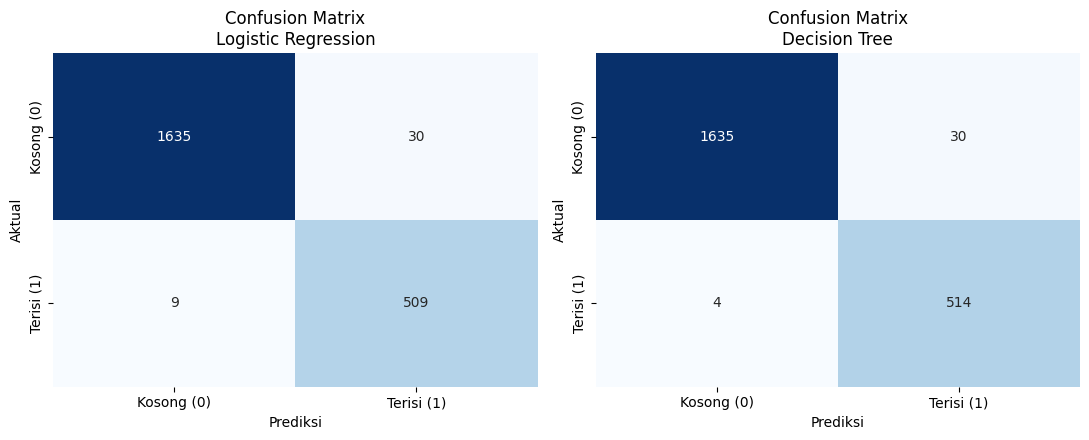

In [19]:
#visualisasi
print("\n" + "=" * 70)
print("6. MEMBUAT VISUALISASI (disimpan sebagai file PNG)")
print("=" * 70)

# --- Confusion Matrix heatmap untuk kedua model ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nama, cm) in zip(
    axes, [("Logistic Regression", hasil_lr["Confusion Matrix"]),
           ("Decision Tree", hasil_dt["Confusion Matrix"])]
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Kosong (0)", "Terisi (1)"],
                yticklabels=["Kosong (0)", "Terisi (1)"], ax=ax)
    ax.set_title(f"Confusion Matrix\n{nama}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150)
print("Tersimpan: confusion_matrix_comparison.png")

Tersimpan: roc_curve_comparison.png


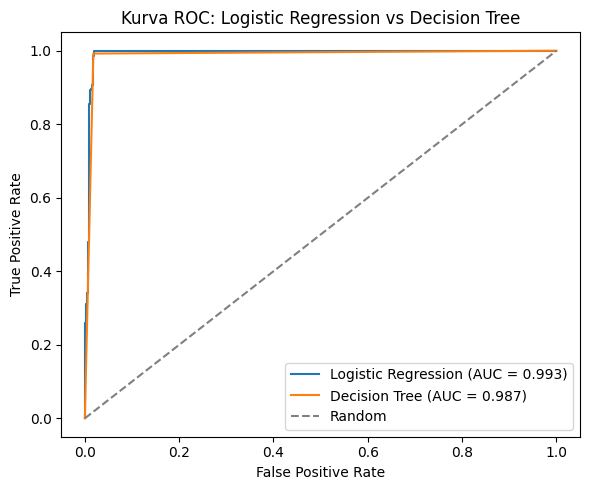

In [20]:
# --- Kurva ROC untuk kedua model ---
plt.figure(figsize=(6, 5))
for nama, y_proba in [("Logistic Regression", y_proba_lr), ("Decision Tree", y_proba_dt)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nama} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Kurva ROC: Logistic Regression vs Decision Tree")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_comparison.png", dpi=150)
print("Tersimpan: roc_curve_comparison.png")

Tersimpan: perbandingan_metrik.png


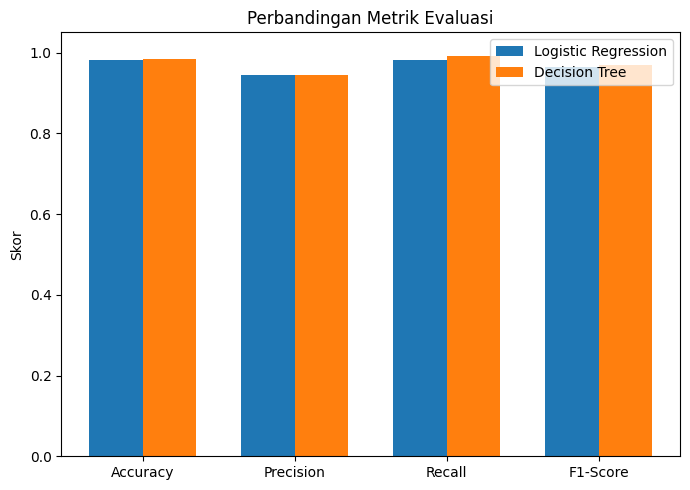

In [21]:
# --- Bar chart perbandingan metrik ---
metrik = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrik))
lebar = 0.35
plt.figure(figsize=(7, 5))
plt.bar(x - lebar / 2, tabel_perbandingan.loc[0, metrik], lebar, label="Logistic Regression")
plt.bar(x + lebar / 2, tabel_perbandingan.loc[1, metrik], lebar, label="Decision Tree")
plt.xticks(x, metrik)
plt.ylim(0, 1.05)
plt.ylabel("Skor")
plt.title("Perbandingan Metrik Evaluasi")
plt.legend()
plt.tight_layout()
plt.savefig("perbandingan_metrik.png", dpi=150)
print("Tersimpan: perbandingan_metrik.png")

Tersimpan: koefisien_logistic_regression.png


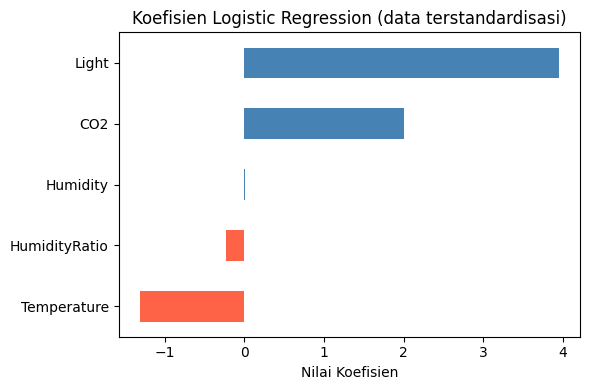

In [22]:
# --- Koefisien Logistic Regression (interpretasi arah pengaruh variabel) ---
koef_lr = pd.Series(model_lr.coef_[0], index=fitur).sort_values()
plt.figure(figsize=(6, 4))
koef_lr.plot(kind="barh", color=["tomato" if v < 0 else "steelblue" for v in koef_lr])
plt.title("Koefisien Logistic Regression (data terstandardisasi)")
plt.xlabel("Nilai Koefisien")
plt.tight_layout()
plt.savefig("koefisien_logistic_regression.png", dpi=150)
print("Tersimpan: koefisien_logistic_regression.png")

Tersimpan: feature_importance_decision_tree.png


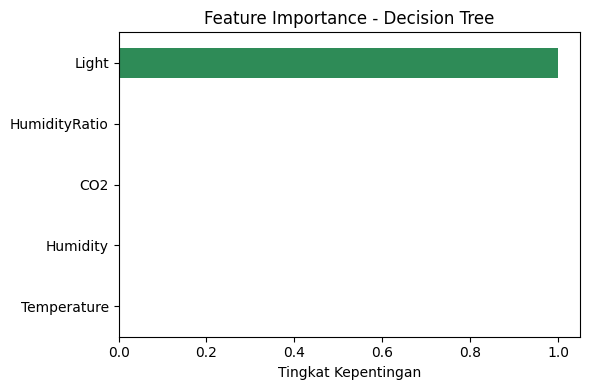

In [23]:
# --- Feature importance Decision Tree ---
importance_dt = pd.Series(model_dt.feature_importances_, index=fitur).sort_values()
plt.figure(figsize=(6, 4))
importance_dt.plot(kind="barh", color="seagreen")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Tingkat Kepentingan")
plt.tight_layout()
plt.savefig("feature_importance_decision_tree.png", dpi=150)
print("Tersimpan: feature_importance_decision_tree.png")

Tersimpan: struktur_decision_tree.png


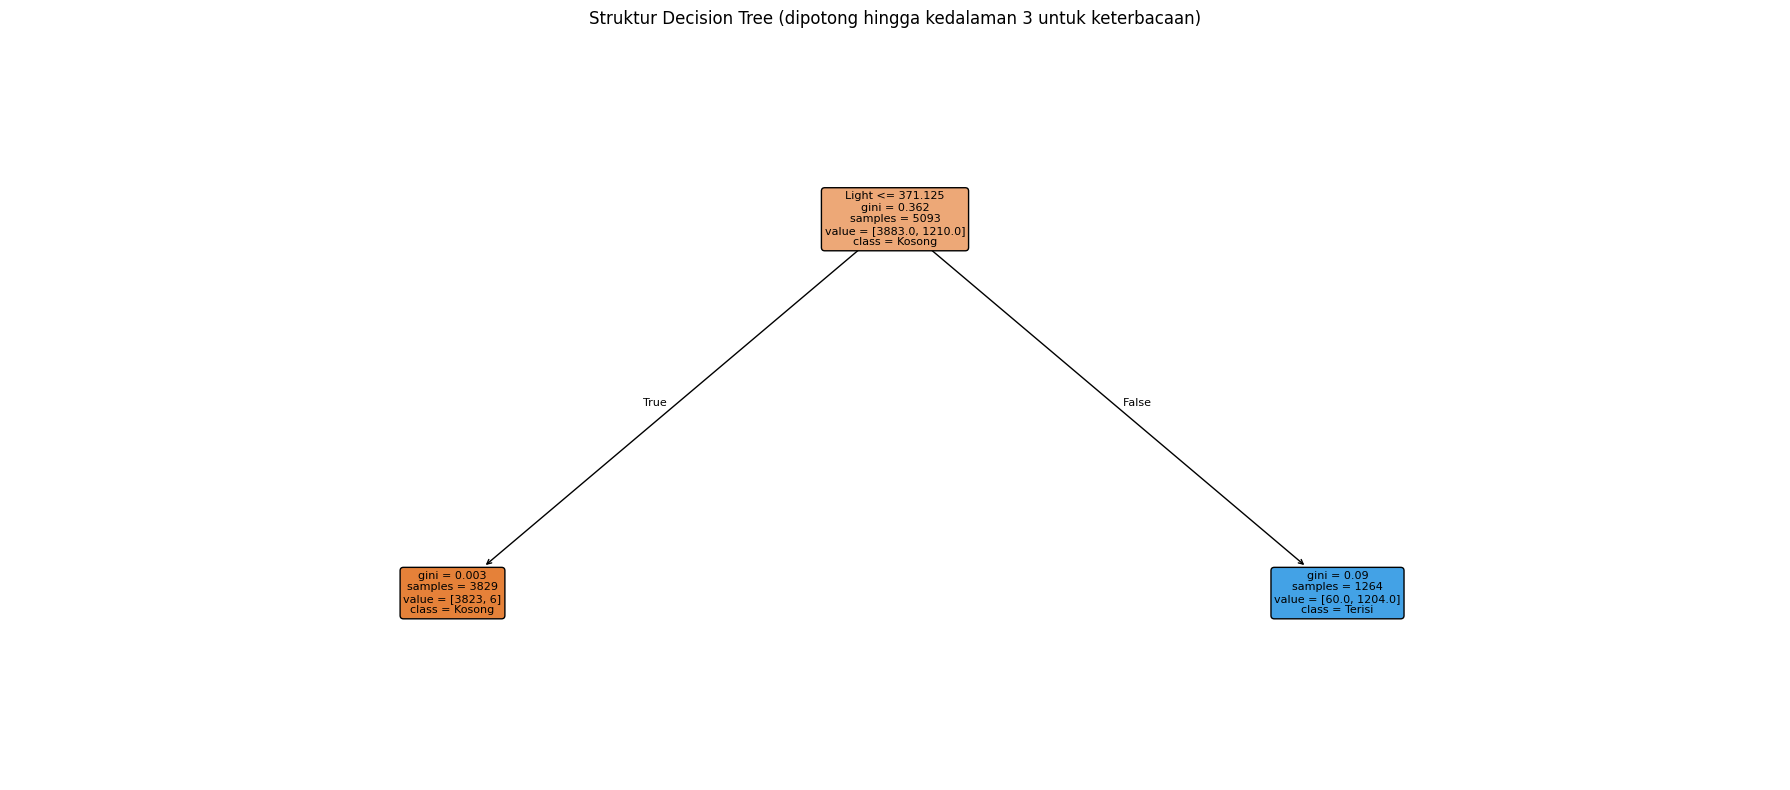

In [24]:
# --- Visualisasi struktur pohon (Decision Tree)
plt.figure(figsize=(18, 8))
plot_tree(model_dt, feature_names=fitur, class_names=["Kosong", "Terisi"],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Struktur Decision Tree (dipotong hingga kedalaman 3 untuk keterbacaan)")
plt.tight_layout()
plt.savefig("struktur_decision_tree.png", dpi=150)
print("Tersimpan: struktur_decision_tree.png")

Tersimpan: struktur_decision_tree_lengkap.png


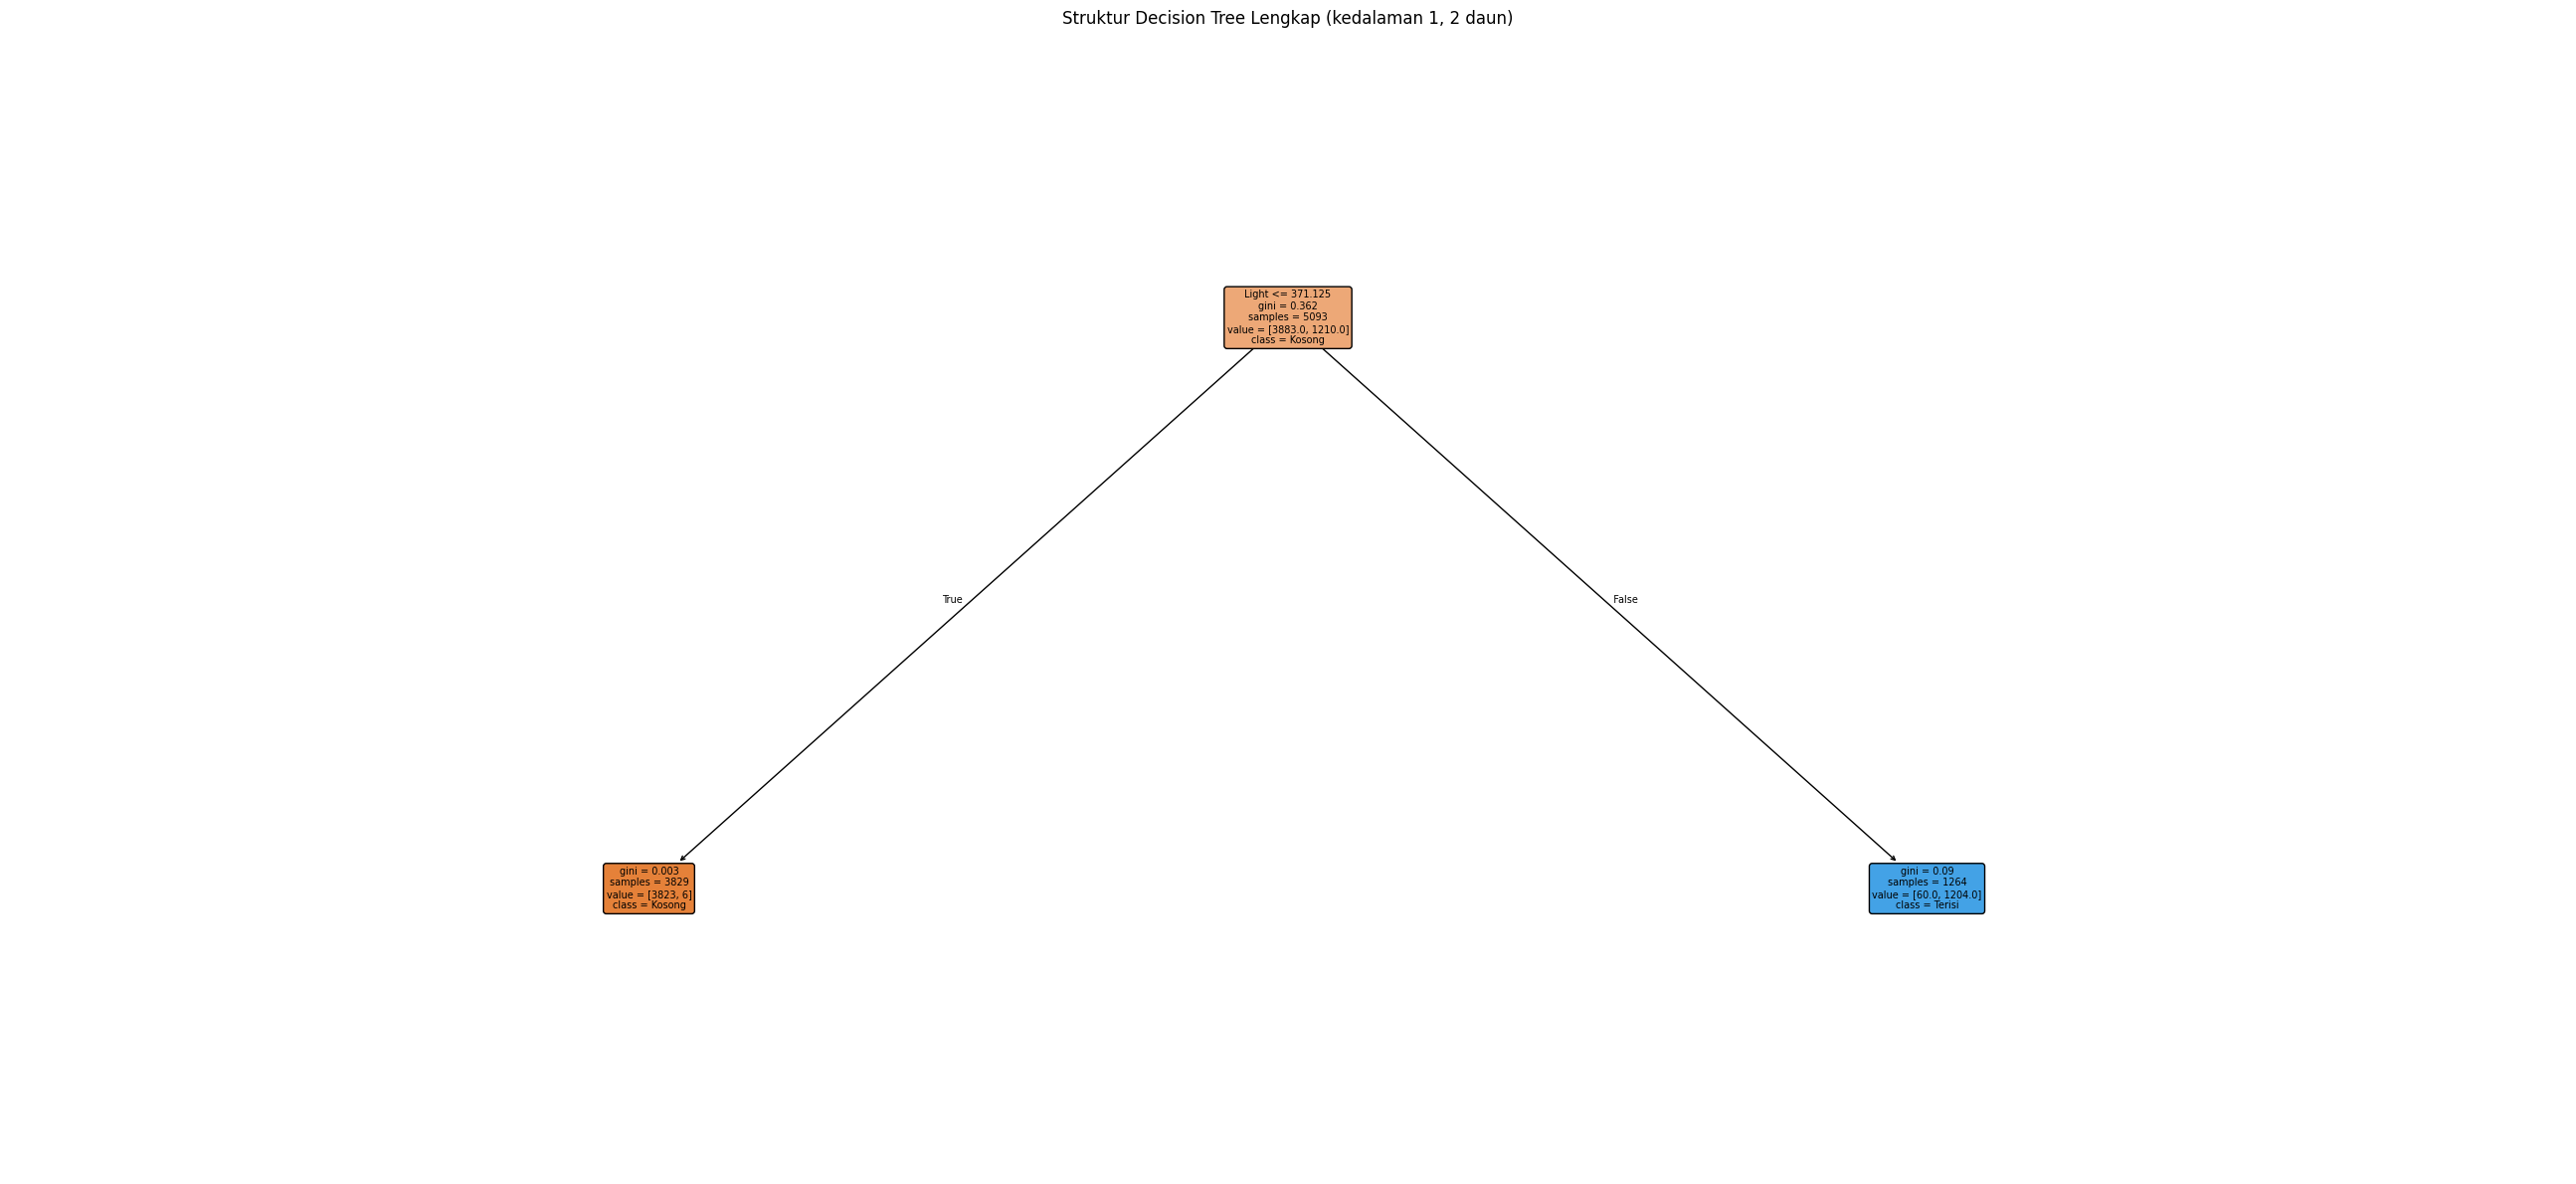

In [26]:
# Versi lengkap (seluruh kedalaman = max_depth model, tanpa dipotong)
plt.figure(figsize=(26, 12))
plot_tree(model_dt, feature_names=fitur, class_names=["Kosong", "Terisi"],
          filled=True, rounded=True, fontsize=7)
plt.title(f"Struktur Decision Tree Lengkap (kedalaman {model_dt.get_depth()}, "
          f"{model_dt.get_n_leaves()} daun)")
plt.tight_layout()
plt.savefig("struktur_decision_tree_lengkap.png", dpi=150)
print("Tersimpan: struktur_decision_tree_lengkap.png")

In [27]:
#interpretasi
print("\n" + "=" * 70)
print("7. CATATAN INTERPRETASI UNTUK LAPORAN")
print("=" * 70)
print(f"""
- Variabel dengan koefisien Logistic Regression terbesar (nilai absolut):
  {koef_lr.abs().sort_values(ascending=False).index[0]}
- Variabel dengan feature importance tertinggi pada Decision Tree:
  {importance_dt.sort_values(ascending=False).index[0]}
- Pada split testing 70/30 (dari Training), akurasi tertinggi: {model_terbaik}
- TEMUAN UTAMA (validasi eksternal Test & Test2):
  Selisih akurasi (testing 70/30 - rata-rata eksternal) per model: {gap_leakage.to_dict()}
  Decision Tree awalnya (tanpa pemangkasan/dengan max_depth tetap) sangat
  overfit -- unggul di testing 70/30 tapi akurasinya anjlok signifikan di
  data eksternal (indikasi leakage akibat autokorelasi waktu). Setelah
  ccp_alpha dipilih lewat validasi luar-waktu (Test & Test2), Decision Tree
  menjadi pohon sangat sederhana (1 split, berbasis variabel Light) yang
  justru stabil atau lebih baik di data eksternal dibanding Logistic
  Regression -- menunjukkan bahwa untuk dataset ini, model paling sederhana
  yang paling general, bukan yang paling kompleks.
- Kaitkan temuan ini dengan konteks nyata: variabel Light dan CO2 secara umum
  paling informatif untuk mendeteksi keberadaan orang di ruangan, sesuai
  logika bahwa lampu menyala dan kadar CO2 meningkat saat ruangan terisi.
  Untuk deployment nyata (mis. sistem HVAC otomatis), hasil ini menegaskan
  pentingnya menguji model pada data dari rentang waktu berbeda, bukan hanya
  mengandalkan akurasi pada satu split acak.
""")

print("=" * 70)
print("SELESAI. Simpan tabel dan grafik di atas untuk dilampirkan ke laporan.")
print("=" * 70)


7. CATATAN INTERPRETASI UNTUK LAPORAN

- Variabel dengan koefisien Logistic Regression terbesar (nilai absolut):
  Light
- Variabel dengan feature importance tertinggi pada Decision Tree:
  Light
- Pada split testing 70/30 (dari Training), akurasi tertinggi: Decision Tree
- TEMUAN UTAMA (validasi eksternal Test & Test2):
  Selisih akurasi (testing 70/30 - rata-rata eksternal) per model: {'Decision Tree': -0.0010330113657854856, 'Logistic Regression': 0.002632203222454277}
  Decision Tree awalnya (tanpa pemangkasan/dengan max_depth tetap) sangat
  overfit -- unggul di testing 70/30 tapi akurasinya anjlok signifikan di
  data eksternal (indikasi leakage akibat autokorelasi waktu). Setelah
  ccp_alpha dipilih lewat validasi luar-waktu (Test & Test2), Decision Tree
  menjadi pohon sangat sederhana (1 split, berbasis variabel Light) yang
  justru stabil atau lebih baik di data eksternal dibanding Logistic
  Regression -- menunjukkan bahwa untuk dataset ini, model paling sederhana
  yang pa